# **1. Perkenalan Dataset**


Dataset yang digunakan adalah Titanic Dataset. Dataset ini berisi informasi penumpang kapal Titanic, termasuk apakah mereka selamat atau tidak. Tujuannya adalah melakukan analisis faktor-faktor yang mempengaruhi keselamatan penumpang dan menyiapkan data untuk klasifikasi.

# **2. Import Library**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil # Tambahan: Untuk mengompres folder jadi file .zip
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

try:
    from google.colab import files
except ImportError:
    pass

%matplotlib inline

# **3. Memuat Dataset**

In [10]:
# 1. Load dataset
df = sns.load_dataset('titanic')

# 2. Buat folder 'titanic_raw'
output_path = 'titanic_raw' # Menghilangkan '../' agar lebih aman di environment cloud
if not os.path.exists(output_path):
    os.makedirs(output_path)

# 3. Simpan ke CSV
csv_raw_path = f'{output_path}/train.csv'
df.to_csv(csv_raw_path, index=False)
print("Data Loading & Saving Sukses!")

# 4. Tampilkan data
display(df.head())

Data Loading & Saving Sukses!


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# **4. Exploratory Data Analysis (EDA)**


Jumlah Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


/tmp/ipython-input-3443294791.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='survived', data=df, palette='viridis')


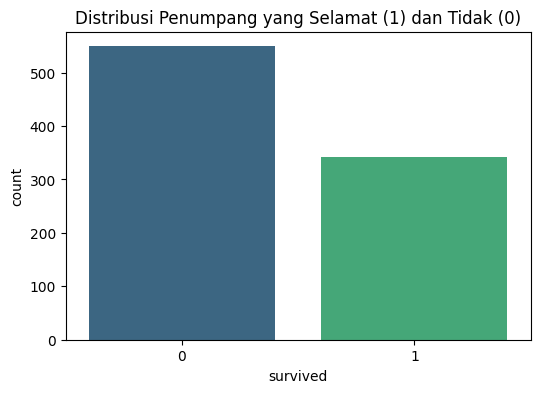

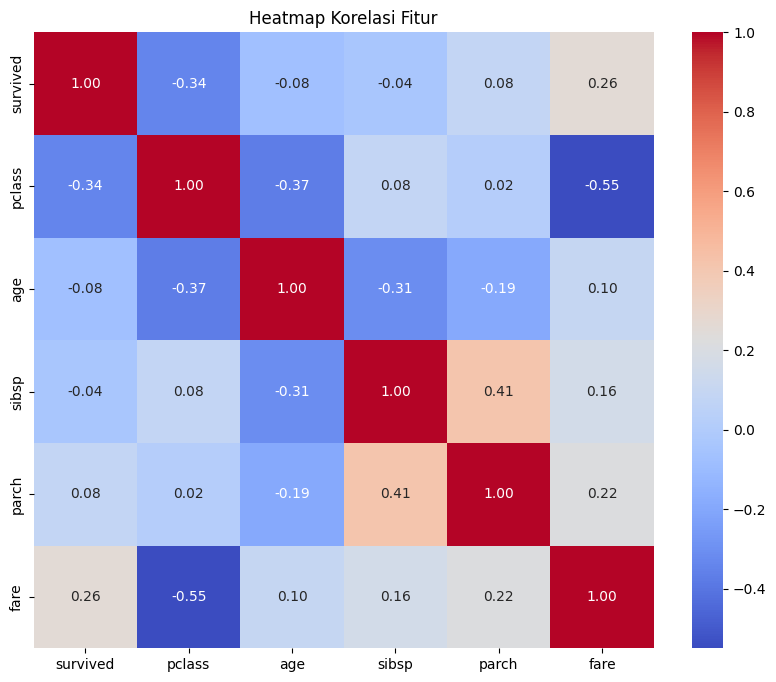

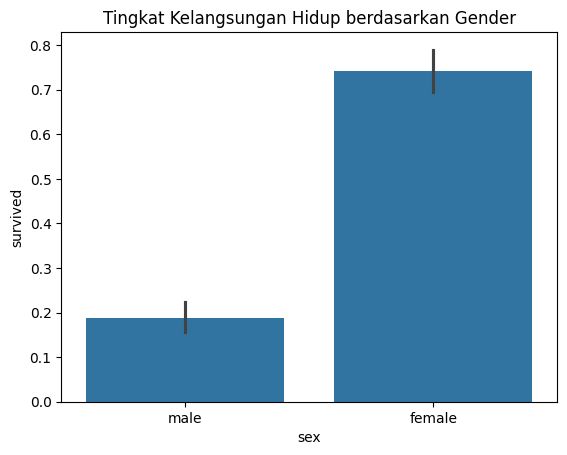

In [7]:
# 1. Cek Missing Values
print("Jumlah Missing Values:")
print(df.isnull().sum())

# 2. Visualisasi Target (Survived)
plt.figure(figsize=(6, 4))
sns.countplot(x='survived', data=df, palette='viridis')
plt.title('Distribusi Penumpang yang Selamat (1) dan Tidak (0)')
plt.show()

# 3. Korelasi antar fitur numerik
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur')
plt.show()

# 4. Hubungan Gender dengan Keselamatan
sns.barplot(x='sex', y='survived', data=df)
plt.title('Tingkat Kelangsungan Hidup berdasarkan Gender')
plt.show()

# **5. Data Preprocessing**

In [8]:
# 1. Menghapus kolom yang tidak relevan (Cleaning)
# Gunakan .copy() agar tidak muncul SettingWithCopyWarning
df_clean = df.drop(['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'], axis=1).copy()

# 2. Menangani Missing Values
# Isi 'age' dengan median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
# Isi 'embarked' dengan modus
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

# 3. Encoding Data Kategorikal
le = LabelEncoder()
df_clean['sex'] = le.fit_transform(df_clean['sex']) # male=1, female=0
df_clean['embarked'] = le.fit_transform(df_clean['embarked'])

# 4. Memisahkan Fitur (X) dan Target (y)
X = df_clean.drop('survived', axis=1)
y = df_clean['survived']

# 5. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Standarisasi Fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing Selesai!")
print(f"Ukuran Data Latih: {X_train_scaled.shape}")
print(f"Ukuran Data Uji: {X_test_scaled.shape}")

# Simpan data hasil preprocessing
df_clean.to_csv('titanic_preprocessed.csv', index=False)

Preprocessing Selesai!
Ukuran Data Latih: (712, 8)
Ukuran Data Uji: (179, 8)
